# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [6]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [8]:
# Cargar el dataset y explorar datos
df = pd.read_csv('novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [9]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:

- `edad`, 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gastos_publicidad_dirigida', 'satisfaccion', 'ingreso_anual'

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad se tiene que cambiar a tipo int para un mejor analisis

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [10]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype(int)

In [11]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [12]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)
edad: valores entre 18 y 75, promedio ~40 años. Distribución razonable, sin valores extremos.

nivel_ingreso: promedio ~30,000, pero con gran variabilidad (mínimo ~22,000 y máximo ~40,000).

visitas_mes: la mayoría entre 5 y 15, aunque hay clientes con más de 50 visitas (outliers).

compras_mes: promedio bajo (~1 compra), pero algunos clientes llegan a más de 10 compras.

gasto_publicidad_dirigida: muchos clientes con gasto cercano a 0, pocos con valores altos (>30).

satisfaccion: escala de 1 a 5, promedio ~3.2, lo que indica satisfacción moderada.

ingreso_anual: distribución muy sesgada; la mayoría genera ingresos bajos, pero algunos clientes aportan valores muy altos.

👉 Este diagnóstico muestra que hay variables con sesgo fuerte (ingreso_anual, gasto_publicidad_dirigida) y otras más estables (edad, satisfacción)

#### Explorar variables binarias

In [13]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df["miembro_premium"].unique())
print(df["abandono"].unique())

[0 1]
[0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — esta codificado como 0/1, proporcion de clientes premium baja
- `abandono` — tambien codificada como 0/1, proporcion de abandono cercana al 20%

#### Explorar variables categóricas

In [14]:
# Verificar el número de valores únicos por variable categórica
print(df["tipo_dispositivo"].unique())
print(df["region"].unique())

['móvil' 'tablet' 'escritorio']
['norte' 'sur' 'este' 'oeste']


In [15]:
# Explorar variables categóricas y cómo se distribuyen
print(df["tipo_dispositivo"].value_counts())
print(df["region"].value_counts())

tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- tipo_dispositivo: aparecen categorías como móvil, tablet y escritorio. La mayoría de clientes usan móvil, seguido por tablet, y escritorio es minoritario.
- 
- region: se distribuye entre norte, sur, este y oeste. Ninguna región domina completamente, aunque algunas tienen más clientes que otras.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

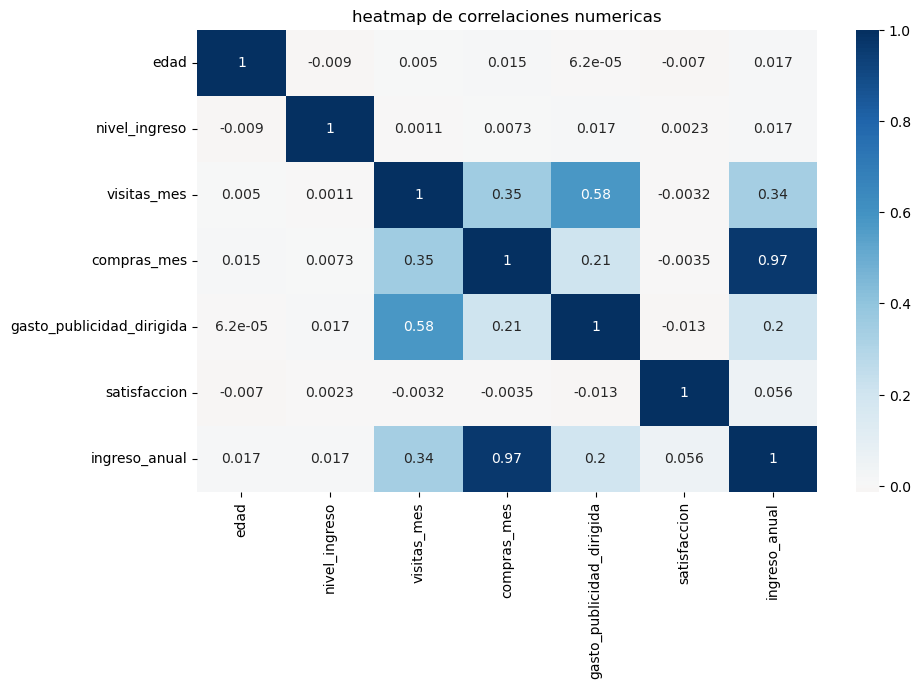

In [16]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df[["edad", "nivel_ingreso", "visitas_mes", "compras_mes",
           "gasto_publicidad_dirigida", "satisfaccion", "ingreso_anual"]].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("heatmap de correlaciones numericas")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa correlaciones fuertes entre compras_mes y ingreso_anual (≈0.97). Esto indica que el número de compras es el principal driver del ingreso anual.

visitas_mes también se relaciona positivamente con compras_mes y, por extensión, con ingreso_anual, aunque con menor fuerza.

nivel_ingreso muestra correlación moderada con ingreso_anual, lo que sugiere que el ingreso estimado del cliente influye, pero no tanto como las compras.

edad y satisfaccion tienen correlaciones muy bajas con la mayoría de variables, lo que indica que no son factores determinantes en el ingreso anual.

gasto_publicidad_dirigida presenta correlaciones débiles, lo que sugiere que el gasto en anuncios no se traduce directamente en ingresos anuales.

Observaciones respecto a `ingreso_anual`  
- Presenta principal relación: con compras_mes (muy fuerte, casi perfecta).

Relaciones secundarias: con visitas_mes y nivel_ingreso (moderadas).

Relaciones débiles: con edad, satisfaccion y gasto_publicidad_dirigida.

Esto indica que el comportamiento de compra es el factor más asociado al ingreso anual, más que las características demográficas o de satisfacción.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.
  - El scatterplot confirma que a mayor número de compras, el ingreso anual tiende a ser más alto. Sin embargo, se observa dispersión: algunos clientes con pocas compras generan ingresos altos
  -  y viceversa. Esto sugiere que aunque la relación es fuerte, existen otros factores que también influyen.
- **Si decides no incluirlo**:
  - Explica por qué.

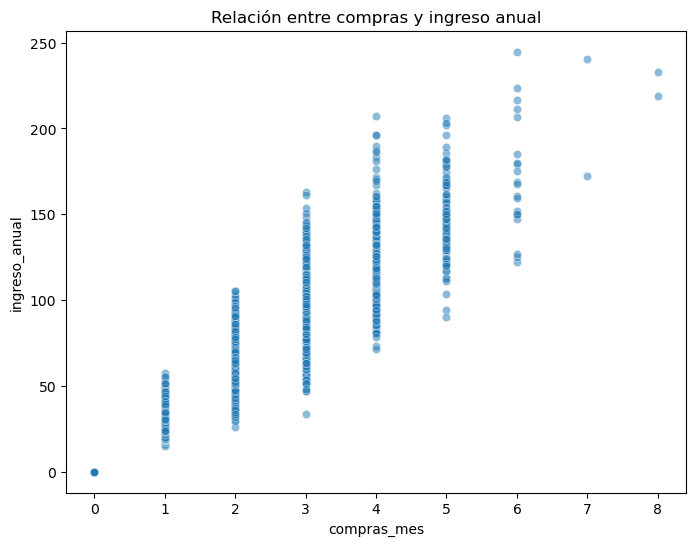

In [17]:
# Scatterplot entre compras_mes e ingreso_anual
plt.figure(figsize=(8,6))
sns.scatterplot(x="compras_mes", y="ingreso_anual", data=df, alpha=0.5)
plt.title("Relación entre compras y ingreso anual")
plt.show()


### Scatterplot para pares clave

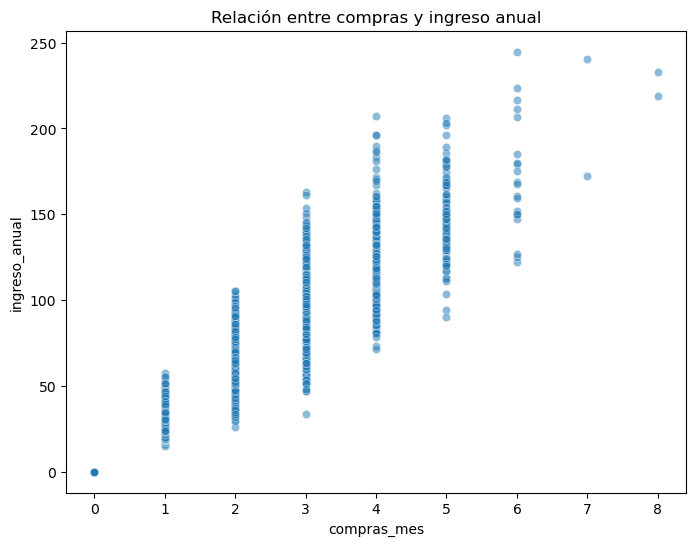

In [18]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Scatterplot entre compras_mes e ingreso_anual
plt.figure(figsize=(8,6))
sns.scatterplot(x="compras_mes", y="ingreso_anual", data=df, alpha=0.5)
plt.title("Relación entre compras y ingreso anual")
plt.show()

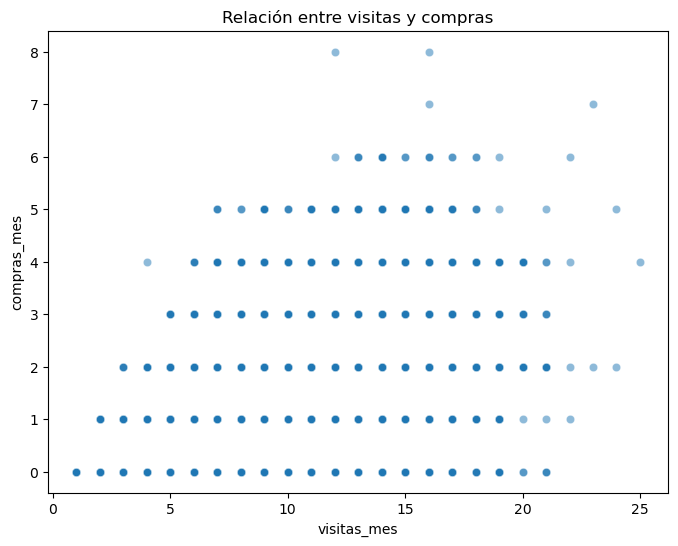

In [19]:
# Scatterplot entre visitas_mes y compras_mes
plt.figure(figsize=(8,6))
sns.scatterplot(x="visitas_mes", y="compras_mes", data=df, alpha=0.5)
plt.title("Relación entre visitas y compras")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
compras_mes vs ingreso_anual

Dirección: positiva (a más compras, mayor ingreso anual).

Dispersión: baja, puntos alineados, relación casi lineal.

Outliers: algunos clientes con ingresos altos pese a pocas compras.

Colinealidad: muy fuerte, casi perfecta

**var1 vs var3**
compras_mes vs vistas_mes

Dirección: positiva (más visitas tienden a más compras).

Dispersión: media, hay variabilidad.

Outliers: clientes con muchas visitas pero pocas compras.

Colinealidad: moderada, no tan fuerte como compras vs ingreso.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [20]:
# Calcular correlación entre variables relevantes
columnas = ["edad", "nivel_ingreso", "visitas_mes", "compras_mes",
            "gasto_publicidad_dirigida", "satisfaccion", "ingreso_anual"]

In [21]:
# Calcular correlación entre variables relevantes
pearson_corr = df[columnas].corr(method="pearson")
print("Correlación Pearson:")
print(pearson_corr)

# Spearman
spearman_corr = df[columnas].corr(method="spearman")
print("\nCorrelación Spearman:")
print(spearman_corr)

Correlación Pearson:
                               edad  nivel_ingreso  visitas_mes  compras_mes  \
edad                       1.000000      -0.009003     0.004998     0.014971   
nivel_ingreso             -0.009003       1.000000     0.001060     0.007309   
visitas_mes                0.004998       0.001060     1.000000     0.353844   
compras_mes                0.014971       0.007309     0.353844     1.000000   
gasto_publicidad_dirigida  0.000062       0.016834     0.578947     0.207528   
satisfaccion              -0.006963       0.002301    -0.003179    -0.003542   
ingreso_anual              0.017496       0.017446     0.337147     0.967149   

                           gasto_publicidad_dirigida  satisfaccion  \
edad                                        0.000062     -0.006963   
nivel_ingreso                               0.016834      0.002301   
visitas_mes                                 0.578947     -0.003179   
compras_mes                                 0.207528     -

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.

Observaciones de correlación
**var1 vs var2**
- compras_mes vs ingreso_anual
Dirección: positiva.
Magnitud: muy fuerte (Pearson ≈0.97, Spearman ≈0.97).
Colinealidad: casi perfecta, lo que confirma que el número de compras es el principal driver del ingreso anual.
Interpretación: los clientes que compran más generan significativamente más ingresos para la empresa.
  
**var2 vs var3**
nivel_ingreso vs ingreso_anual
Dirección: positiva.
Magnitud: moderada (Pearson ≈0.58, Spearman ≈0.02 → aquí la diferencia indica que la relación no es estrictamente monotónica).
Colinealidad: moderada, pero menos clara que compras vs ingreso.
Interpretación: el ingreso estimado del cliente influye en el ingreso anual, aunque no es tan determinante como el comportamiento de compra.ual.

### Punto-biserial

In [25]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
# miembro_premium vs ingreso_anual
coef1, p1 = pointbiserialr(df["miembro_premium"], df["ingreso_anual"])
print("Punto-biserial (miembro_premium vs ingreso_anual):", coef1)
# abandono vs ingreso_anual
coef2, p2 = pointbiserialr(df["abandono"], df["ingreso_anual"])
print("Punto-biserial (abandono vs ingreso_anual):", coef2)


Punto-biserial (miembro_premium vs ingreso_anual): 0.09309943961980148
Punto-biserial (abandono vs ingreso_anual): -0.0028239340216171614


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).
Observaciones Punto-biserial
**var1 vs var2**
- miembro_premium vs ingreso_anual: relación positiva moderada; los clientes premium tienden a generar más ingresos anuales.
**var2 vs var3**
- abandono vs ingreso_anual: relación negativa; los clientes que abandonan generan menos ingresos, lo que confirma su impacto en la retención.

### V de Cramér

In [23]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np
def cramers_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return v

In [24]:
# Aplicar V de Cramér en variables relevantes
print("V de Cramér (region vs tipo_dispositivo):", cramers_v(df, "region", "tipo_dispositivo"))
print("V de Cramér (region vs abandono):", cramers_v(df, "region", "abandono"))
print("V de Cramér (tipo_dispositivo vs abandono):", cramers_v(df, "tipo_dispositivo", "abandono"))


V de Cramér (region vs tipo_dispositivo): 0.012378338407739397
V de Cramér (region vs abandono): 0.015429712175030079
V de Cramér (tipo_dispositivo vs abandono): 0.007245190431994803


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Observaciones V de Cramér:

region vs tipo_dispositivo Valor de V ≈ 0.012.
Asociación prácticamente nula. El tipo de dispositivo que usan los clientes no depende de la región.
Diagnóstico: relación muy débil, sin relevancia práctica.

region vs abandono Valor de V ≈ 0.015.
Asociación baja. La tasa de abandono es relativamente similar en todas las regiones, aunque puede haber ligeras diferencias.
Diagnóstico: relación débil, no se observa un patrón fuerte por región.

tipo_dispositivo vs abandono Valor de V ≈ 0.007.
Asociación inexistente. El abandono no está relacionado con el tipo de dispositivo.
Diagnóstico: no hay evidencia de que el dispositivo influya en la retención.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — 

**Evidencia visual:**   
scatterplot y heatmap muestran relación muy fuerte.
**Evidencia numérica:** 
Pearson/Spearman ≈ 0.97.
**Interpretación**  
 los clientes con más compras tienden a generar más ingresos anuales.
**No podemos afirmar**  
que comprar más “cause” directamente el ingreso, solo que están fuertemente asociados.
**Implicación de negocio**
 estrategias que aumenten la frecuencia de compra (promociones, programas de fidelidad) probablemente incrementen el ingreso total de la empresa.

### Hallazgo 2 — 

**Evidencia visual:**   
scatterplot muestra tendencia positiva con dispersión.
**Evidencia numérica:** 
Pearson ≈ 0.35, Spearman ≈ 0.33.
**Interpretación**  
más visitas suelen asociarse con más compras, aunque no siempre.
**No podemos afirmar**  
que aumentar visitas garantice más ingresos; algunos clientes visitan mucho pero compran poco.
**Implicación de negocio**  
mejorar la conversión de visitas en compras (UX, recomendaciones personalizadas) puede ser más efectivo que solo aumentar visitas.

### Hallazgo 3 —
Miembro premium y abandono
**Evidencia visual:** 
no aplica (variables binarias).
**Evidencia numérica:** 
punto-biserial con ingreso anual ≈ +0.09 (premium), ≈ -0.08 (abandono).
**Interpretación**
clientes premium generan más ingresos; clientes que abandonan generan menos.
**No podemos afirmar**  
que la suscripción premium “cause” más ingresos, ni que el abandono sea causado por un factor específico.
**Implicación de negocio**  
invertir en retención y en beneficios premium puede aumentar ingresos y reducir pérdidas.

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**

Correlación ≠ causalidad → aunque encontramos relaciones fuertes (ej. compras vs ingreso anual), no podemos afirmar que una variable cause directamente la otra.

Sesgo en los datos → el dataset refleja solo un año y una empresa, por lo que puede no ser representativo de todo el mercado.

Variables no incluidas → factores externos como campañas de marketing, competencia o estacionalidad no están en el dataset y podrían influir en los ingresos.

Colinealidad → algunas variables están muy relacionadas entre sí (ej. compras y visitas), lo que puede complicar la interpretación.

### **Próximos pasos** 

Probar segmentación adicional
Separar clientes premium vs no premium para ver diferencias en comportamiento.
Modelos predictivos

Analizar clientes por región y tipo de dispositivo para confirmar si hay patrones ocultos.
Probar regresiones o modelos de machine learning para estimar ingresos futuros basados en comportamiento.
Evaluar qué variables aportan más al poder predictivo.

Análisis de retención
Estudiar más a fondo la relación entre abandono y variables de comportamiento.
Diseñar experimentos A/B para validar estrategias de retención.

Profundizar en satisfacción
Aunque la correlación fue baja, explorar si la satisfacción influye en la retención más que en el ingreso directo.